In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

from blackhole.constants import M_sun
from blackhole.disk_physics import R_func, X_func, kinematic_viscosity
from blackhole.luminosity import L_rad_array, T_eff

# ---------------------------------------------------------------------------
# BH irrad+evap parameters (must match gpu_bh_iradevap simulation notebook)
# ---------------------------------------------------------------------------
M_star = 9 * M_sun

R_1 = 5e8
R_K = 2.2e11
R_N = 4.2e11
N_n = 3

In [2]:
# ---------------------------------------------------------------------------
# Load simulation data
# ---------------------------------------------------------------------------
DATA_PREFIX = "../../data/"
DATA_SUFFIX = "_history_bath_array_irev_gpu.csv"

Sigma_history = np.array(
    pd.read_csv(DATA_PREFIX + "Sigma" + DATA_SUFFIX, header=None).to_numpy()
)
Temp_history = np.array(
    pd.read_csv(DATA_PREFIX + "Temp" + DATA_SUFFIX, header=None).to_numpy()
)
H_history = np.array(
    pd.read_csv(DATA_PREFIX + "H" + DATA_SUFFIX, header=None).to_numpy()
)
alpha_history = np.array(
    pd.read_csv(DATA_PREFIX + "alpha" + DATA_SUFFIX, header=None).to_numpy()
)
t_history = np.array(
    pd.read_csv(DATA_PREFIX + "t" + DATA_SUFFIX, header=None).to_numpy().flatten()
)
Sigma_transfer_history = np.array(
    pd.read_csv(DATA_PREFIX + "Sigma_transfer" + DATA_SUFFIX, header=None).to_numpy().flatten()
)

# ---------------------------------------------------------------------------
# Build grid from data shape (adapts to whatever N the simulation used)
# ---------------------------------------------------------------------------
N = Sigma_history.shape[1]
N_base = N - N_n

X_1 = X_func(R_1)
X_N = X_func(R_N)
X = np.linspace(X_1, X_N, N_base)
dX = float(np.diff(X)[0])
X = np.linspace(X_1, X_N + N_n * dX, N)
r = R_func(X)
dr = np.diff(r)
dr = np.insert(dr, 0, 0)
X_N = X[-1]

print(f"Loaded {len(t_history)} snapshots, t = [{t_history[0]:.2e}, {t_history[-1]:.2e}] s")
print(f"Sigma shape: {Sigma_history.shape}, N_base = {N_base}")

Loaded 40001 snapshots, t = [0.00e+00, 6.39e+08] s
Sigma shape: (40001, 1003), N_base = 1000


In [3]:
# ---------------------------------------------------------------------------
# Compute luminosity arrays
# ---------------------------------------------------------------------------
# Physical caps for GPU simulations (N=10,000). At this resolution some cells
# can develop numerically divergent Sigma due to stiff outburst fronts.
# The source luminosity module guards against inf/nan overflow; here we
# additionally cap per-annulus luminosity at L_edd (Eddington limit) and
# skip the innermost boundary cells.
L_edd = 1.3e38 * (M_star / M_sun)  # Eddington luminosity (erg/s)
N_skip = max(1, N // 100)  # skip innermost ~100 cells (boundary region)

L_rad_arr = np.vstack([
    L_rad_array(Sigma_history[i], H_history[i], alpha_history[i], r, dr, M_star)
    for i in range(len(t_history))
])
L_rad_arr[:, :N_skip] = 0.0
L_rad_arr = np.clip(L_rad_arr, 0.0, L_edd)
L_array = L_rad_arr.sum(axis=1)

T_eff_arr = np.vstack([
    T_eff(Sigma_history[i], H_history[i], alpha_history[i], r, M_star)
    for i in range(len(t_history))
])

print(f"L_edd = {L_edd:.2e} erg/s")
print(f"L range: [{L_array.min():.2e}, {L_array.max():.2e}] erg/s")

L_edd = 1.17e+39 erg/s
L range: [6.78e+26, 1.28e+35] erg/s


In [4]:
# ---------------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------------
SECONDS_PER_YEAR = 31536000


def setup_ticks(ax):
    ax.tick_params(axis='both', which='major', direction='in',
                   length=16, width=2)
    ax.tick_params(axis='both', which='minor', direction='in',
                   length=8, width=2)
    ax.tick_params(axis='both', which='both',
                   top=True, right=True, direction='in')
    ax.tick_params(labeltop=False, labelright=False)

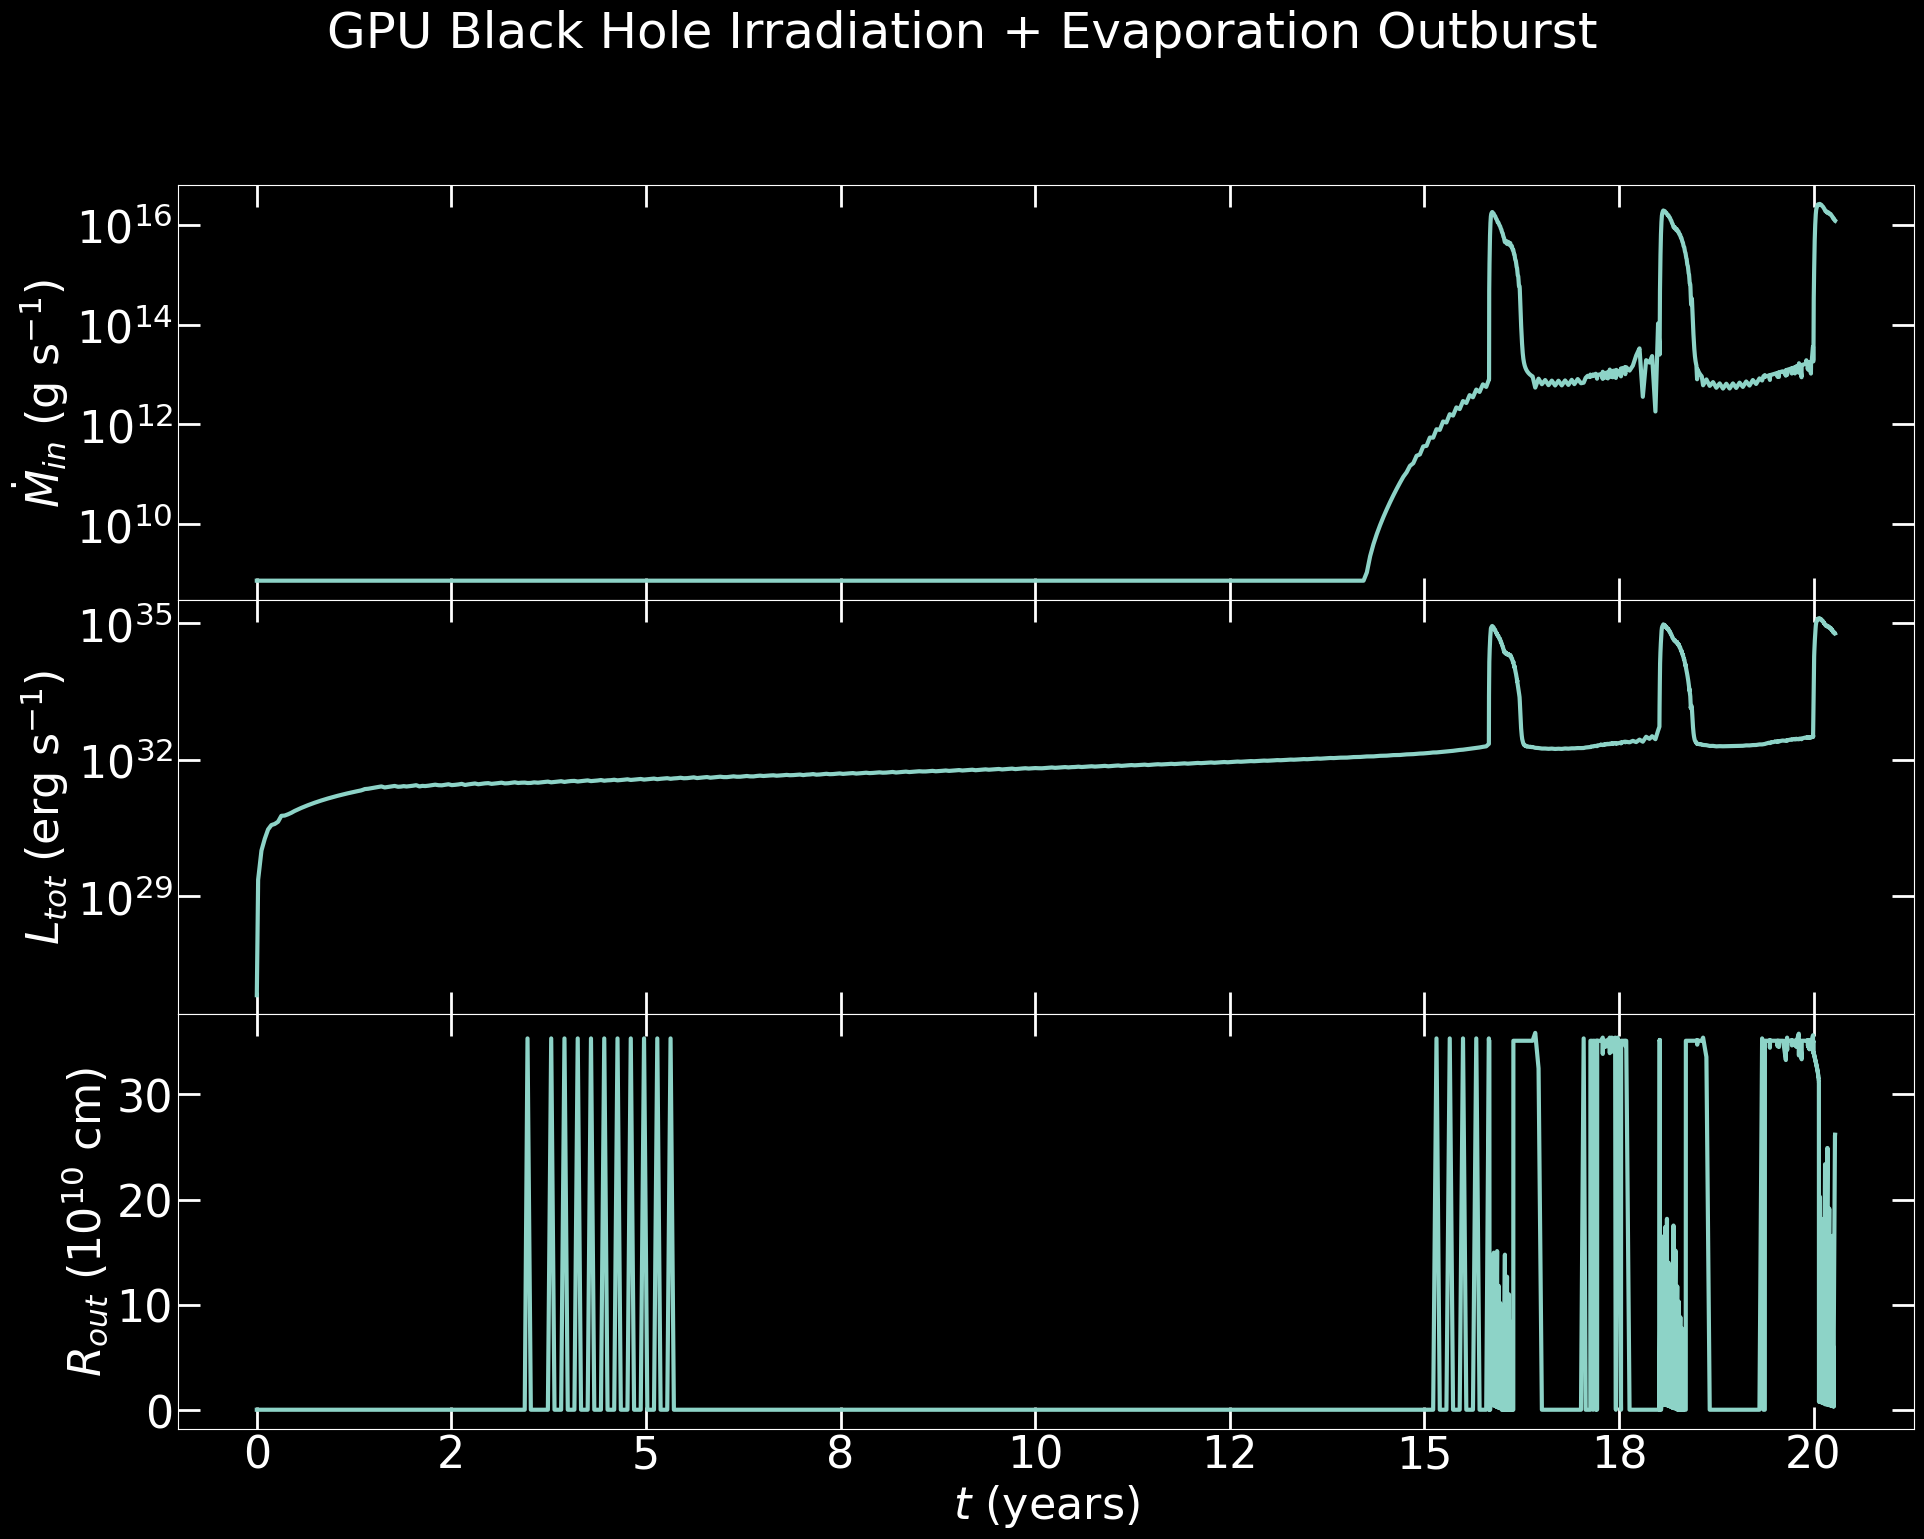

In [5]:
# ---------------------------------------------------------------------------
# Plot: Mass transfer rate, Luminosity, Outer radius vs time
# ---------------------------------------------------------------------------
plt.rcParams.update({'font.size': 32})

# Inner-edge mass accretion rate: M_dot_in = 2*pi*r * Sigma * 3*nu / r
# Use N_skip as the inner index — matches the CPU grid's first resolved cell.
index = N_skip
M_dot_in = np.array([
    2 * np.pi * r[index] * Sigma_history[i, index] * 3
    * kinematic_viscosity(H_history[i, index], r[index],
                          alpha_history[i, index], M_star)
    / r[index]
    for i in range(len(t_history))
])
# Cap at Eddington accretion rate (L_edd / (eta * c^2), eta ~ 0.1)
M_dot_edd = L_edd / (0.1 * (3e10) ** 2)
M_dot_in = np.clip(np.where(np.isfinite(M_dot_in), M_dot_in, 0.0), 0.0, M_dot_edd)

# Outer radius: Sigma-based metric for irradiated disks.
# The standard T < 5000 K metric fails when irradiation heats the outer disk
# above 5000 K in quiescence. Instead, track the last cell with Sigma
# significantly above the floor — this traces the hot outburst front.
min_Sigma = 1e-5
sigma_threshold = 1e7 * min_Sigma  # 1e-3 g/cm^2
first_indices = np.full(Sigma_history.shape[0], 1)
for ts in range(Sigma_history.shape[0]):
    above = np.where(Sigma_history[ts, 3:] > sigma_threshold)[0]
    if above.size > 0:
        first_indices[ts] = above[-1] + 3  # last cell above threshold
R_out = r[first_indices] / 1e10  # in units of 10^10 cm

t_years = t_history / SECONDS_PER_YEAR

fig, axs = plt.subplots(3, 1, figsize=(20, 16), gridspec_kw={'hspace': 0})
ax1, ax2, ax3 = axs

# Plain number formatting on all x-axes (must set before hiding labels)
fmt = plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
for ax in axs:
    ax.xaxis.set_major_formatter(fmt)

# --- Mass transfer rate ---
ax1.plot(t_years, M_dot_in, linewidth=3, color='C0')
ax1.set_ylabel(r'$\dot{M}_{in}$ (g s$^{-1}$)')
ax1.set_yscale('log')
ax1.tick_params(labelbottom=False)
setup_ticks(ax1)

# --- Luminosity ---
ax2.plot(t_years, L_array, linewidth=3, color='C0')
ax2.set_ylabel(r'$L_{tot}$ (erg s$^{-1}$)')
ax2.set_yscale('log')
ax2.tick_params(labelbottom=False)
setup_ticks(ax2)

# --- Outer radius ---
ax3.plot(t_years, R_out, linewidth=3, color='C0')
ax3.set_xlabel(r'$t$ (years)')
ax3.set_ylabel(r'$R_{out}$ ($10^{10}$ cm)')
setup_ticks(ax3)

fig.suptitle('GPU Black Hole Irradiation + Evaporation Outburst', fontsize=36, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../../graphs/gpu_bh_iradevap_outburst.png', dpi=150, bbox_inches='tight')
plt.show()